In [62]:
# %pip install -qU google-generativeai
# %pip install -qU google-ai-generativelanguage==0.6.15
# %pip install -qU langchain-google-genai
# %pip install -qU langchain-community
# %pip install -qU langgraph
# %pip install -qU langgraph langchain-community
# %pip install -qU python-dotenv

In [63]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List, Sequence, Union
import operator
import google.generativeai as genai
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage, BaseMessage
from langchain_community.tools.tavily_search import TavilySearchResults

In [64]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [65]:
import os
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = os.getenv('GEMINI_API_KEY') 
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

In [66]:
tool = TavilySearchResults(max_results=4)
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


In [67]:
class Agent:
    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_gemini)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_gemini(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Llamado a la herramienta: {t}")
            if not t['name'] in self.tools:
                print("\n ....Nombre de herramienta desconocido....")
                result = "Nombre de herramienta desconocido, intente de nuevo"
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Volviendo al modelo!")
        return {'messages': results}

In [68]:
# %pip install -U langchain-tavily

In [70]:
prompt = """Eres un asistente de investigación inteligente. Utiliza el motor de búsqueda para buscar información. \
Tienes permiso para realizar múltiples consultas (ya sea de forma conjunta o secuencial). \
Busca información únicamente cuando tengas claro lo que deseas. \
Si necesitas investigar alguna información antes de hacer una pregunta de seguimiento, ¡tienes permiso para hacerlo!
"""

model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)

abot = Agent(model, [tool], system=prompt)

In [71]:
mermaid_code = abot.graph.get_graph().draw_mermaid()
print(mermaid_code)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	llm(llm)
	action(action)
	__end__([<p>__end__</p>]):::last
	__start__ --> llm;
	action --> llm;
	llm -. &nbsp;False&nbsp; .-> __end__;
	llm -. &nbsp;True&nbsp; .-> action;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



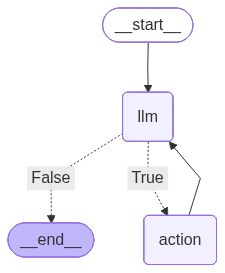

In [72]:
from IPython.display import Image, display

try:
    
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))

except Exception as e:
    print(f"Error al tratar generar el PNG de Mermaid: {e}")
    print("\nVerifique que la versión de LangGraph posee el método `.draw_mermaid_png()`.")
    print("Como alternativa, use `.draw_mermaid()` para obtener la string y visualizarla externamente.")

In [73]:
prompt = """Eres un asistente de investigación inteligente. Utiliza el motor de búsqueda para buscar información. \
Tienes permiso para realizar múltiples consultas (ya sea de forma conjunta o secuencial). \
Busca información únicamente cuando tengas claro lo que deseas. \
Si necesitas investigar alguna información antes de hacer una pregunta de seguimiento, ¡tienes permiso para hacerlo!
"""
model_instance = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)
tool_instance = TavilySearchResults(max_results=4)

abot = Agent(model_instance, [tool_instance], system=prompt)

messages = [HumanMessage(content="Cómo está el clima en Pereira hoy?")]

print("Iniciando la interacción con el agente:")
final_result_state = None

for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Ningún resultado final o resultado inesperado.")

Iniciando la interacción con el agente:
{'llm': {'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "clima en Pereira hoy"}'}, '__gemini_function_call_thought_signatures__': {'4IvEY68c': 'EjQKMgERTTIPAobozheERK/hRjAQDn072iJF4e/xJbSBi3J4/lhwP+2rhYROdEsqPM6UtBFD'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f4cba-1efc-7e21-81f3-7ed84182af15-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'clima en Pereira hoy'}, 'id': '4IvEY68c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 159, 'output_tokens': 26, 'total_tokens': 185, 'input_token_details': {'cache_read': 0}})]}}
---
Llamado a la herramienta: {'name': 'tavily_search_results_json', 'args': {'query': 'clima en Pereira hoy'}, 'id': '4IvEY68c', 'type': 'tool_call'}
Volviendo al modelo!
{'ac

In [75]:
from datetime import date
current_date = date.today().strftime("%d/%m/%Y") # Formato dd/mm/aaaa

prompt = f"""
Eres un asistente de investigación inteligente y altamente actualizado. \
Tu principal prioridad es encontrar la información más RECIENTE y EN TIEMPO REAL siempre que sea posible. \
La fecha actual es {current_date}. \
Al buscar sobre el clima o eventos que se refieran a "hoy" o "ahora", \
DEBES **incluir la fecha actual '{current_date}' en tu consulta para la herramienta de búsqueda**. \
Por ejemplo, si la pregunta es "clima en ciudad x hoy", la consulta para la herramienta debe ser "clima en ciudad x {current_date}". \
Ignora o descarta información que claramente se refiera a fechas pasadas o futuras al responder preguntas sobre "hoy". \
Utiliza el motor de búsqueda para buscar información, procurando siempre el "hoy" o el "ahora" cuando el contexto lo indique. \
Tienes permiso para realizar múltiples llamadas (ya sea en conjunto o en secuencia). \
Busca información solo cuando tengas claro lo que deseas. \
Si necesitas investigar alguna información antes de hacer una pregunta de seguimiento, ¡tienes permiso para hacerlo!
"""

model_instance = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)
tool_instance = TavilySearchResults(max_results=4)
abot = Agent(model_instance, [tool_instance], system=prompt)

user_query = "Cómo está el clima en Trenque Lauquen hoy?"

messages = [HumanMessage(content=user_query)]

print("Iniciando la interacción con el agente:")
final_result_state = None
for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Ningún resultado final o resultado inesperado.")

Iniciando la interacción con el agente:
{'llm': {'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "clima en Trenque Lauquen 10/07/2026"}'}, '__gemini_function_call_thought_signatures__': {'9dBp97YB': 'EjQKMgERTTIPWG1AwJhPGlbSc+JxPLj7aUmDR92eNgPNzc5LTO+m4diJ4qNl/NSHvbiM5CNZ'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f4cbe-d167-72c2-934a-e86ebefadb7c-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'clima en Trenque Lauquen 10/07/2026'}, 'id': '9dBp97YB', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 334, 'output_tokens': 39, 'total_tokens': 373, 'input_token_details': {'cache_read': 0}})]}}
---
Llamado a la herramienta: {'name': 'tavily_search_results_json', 'args': {'query': 'clima en Trenque Lauquen 10/07/2026'}, 'id': '9dBp97YB', '

In [76]:
user_query_tomorrow = "Cómo estará el clima de Trenque Lauquen mañana?" #actualizamos solamente la pregunta del usuario

messages_tomorrow = [HumanMessage(content=user_query_tomorrow)]

print("\n--- Iniciando la interacción con el agente para mañana---")
final_result_state_tomorrow = None
for s in abot.graph.stream({"messages": messages_tomorrow}):
    print(s)
    print("---")
    final_result_state_tomorrow = s

print("\n--- Resultado Final para mañana ---")
if final_result_state_tomorrow and 'llm' in final_result_state_tomorrow and final_result_state_tomorrow['llm']['messages']:
    print(final_result_state_tomorrow['llm']['messages'][-1].content)
else:
    print("Ningún resultado final o resultado inesperado para mañana.")


--- Iniciando la interacción con el agente para mañana---
{'llm': {'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "clima en Trenque Lauquen 11/07/2026"}'}, '__gemini_function_call_thought_signatures__': {'mb4T06L3': 'EjQKMgERTTIPvbtJ5RfjkqoodLG2DbZyFXiJd0E5c1ysDw5LgY17o7KXqudNrnDNGRYL1UUz'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f4cc0-151e-7821-8d12-9df8f04259d5-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'clima en Trenque Lauquen 11/07/2026'}, 'id': 'mb4T06L3', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 334, 'output_tokens': 39, 'total_tokens': 373, 'input_token_details': {'cache_read': 0}})]}}
---
Llamado a la herramienta: {'name': 'tavily_search_results_json', 'args': {'query': 'clima en Trenque Lauquen 11/07/2026'}, 

In [77]:
from langchain_core.messages import HumanMessage

user_query_yesterday = "Cómo fue el clima de Trenque Lauquen ayer?" 

messages_yesterday = [HumanMessage(content=user_query_yesterday)]

print("\n--- Iniciando la interacción con el agente---")
final_result_state_yesterday = None
for s in abot.graph.stream({"messages": messages_yesterday}):
    print(s)
    print("---")
    final_result_state_yesterday = s

print("\n--- Resultado Final  ---")
if final_result_state_yesterday and 'llm' in final_result_state_yesterday and final_result_state_yesterday['llm']['messages']:
    print(final_result_state_yesterday['llm']['messages'][-1].content)
else:
    print("Ningún resultado final o resultado inesperado.")


--- Iniciando la interacción con el agente---
{'llm': {'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "clima en Trenque Lauquen 09/07/2026"}'}, '__gemini_function_call_thought_signatures__': {'vbH3zsN6': 'EjQKMgERTTIP0KcvcPq5iHjaiGPKmwUCrkHYzt3CElhZifcswLtv4Hd6HcUJIWDBxep4Jsmu'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f4cc1-7584-7722-bcdf-eae4a220f3fe-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'clima en Trenque Lauquen 09/07/2026'}, 'id': 'vbH3zsN6', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 334, 'output_tokens': 39, 'total_tokens': 373, 'input_token_details': {'cache_read': 0}})]}}
---
Llamado a la herramienta: {'name': 'tavily_search_results_json', 'args': {'query': 'clima en Trenque Lauquen 09/07/2026'}, 'id': 'vbH3z

In [78]:
messages = [HumanMessage(content="Cómo está el clima en Trenque Lauquen hoy?")] 
result = abot.graph.invoke({"messages": messages})

Llamado a la herramienta: {'name': 'tavily_search_results_json', 'args': {'query': 'clima en Trenque Lauquen 10/07/2026'}, 'id': 'zaoxHrzN', 'type': 'tool_call'}
Volviendo al modelo!


In [79]:
result['messages'][-1].content

[{'type': 'text',
  'text': 'Para hoy, viernes 10 de julio de 2026, el pronóstico del tiempo en Trenque Lauquen indica una jornada fresca y mayormente nublada.\n\nAquí tienes los detalles principales:\n\n*   **Temperatura:** Se espera una máxima de **10°C** y una mínima de **7°C**.\n*   **Estado del cielo:** El día se presenta con cielo cubierto y condiciones de inestabilidad. Se han registrado pronósticos de **lluvias débiles o lloviznas** durante gran parte de la jornada.\n*   **Viento:** Sopla de manera leve a moderada desde el sector sureste, con velocidades promedio de entre 9 y 13 km/h.\n*   **Humedad:** Se mantiene elevada, rondando el 90-96%.\n\nTe recomiendo salir con abrigo y paraguas si debes realizar actividades al aire libre, debido a la alta probabilidad de precipitaciones débiles y la baja temperatura.',
  'extras': {'signature': 'EjQKMgERTTIPW1Mm7BJdd04hxrgt45unRGIugkfhyKhJRSuGb9WQBThgceUX8bmrbpMlVE2y'}}]

In [80]:
messages = [HumanMessage(content="Cómo está el clima en Trenque Lauquen y en CABA hoy?")]
result = abot.graph.invoke({"messages": messages})

Llamado a la herramienta: {'name': 'tavily_search_results_json', 'args': {'query': 'clima en Trenque Lauquen 10/07/2026'}, 'id': 'pc1Sp846', 'type': 'tool_call'}
Llamado a la herramienta: {'name': 'tavily_search_results_json', 'args': {'query': 'clima en CABA 10/07/2026'}, 'id': 'ipXRk2Zk', 'type': 'tool_call'}
Volviendo al modelo!


In [81]:
result['messages'][-1].content

[{'type': 'text',
  'text': 'Para hoy, viernes 10 de julio de 2026, el pronóstico del tiempo en ambas localidades es el siguiente:\n\n### **Trenque Lauquen**\n*   **Condiciones:** El día se presenta con cielo cubierto y probabilidad de lluvias débiles durante gran parte de la jornada.\n*   **Temperaturas:** Se espera una máxima de **10°C** y una mínima de **7°C**.\n*   **Viento:** Vientos leves provenientes principalmente del sector sureste, con una velocidad media de unos 13 km/h.\n*   **Humedad:** Se mantiene elevada, con valores cercanos al 90-96%.\n\n### **CABA (Ciudad Autónoma de Buenos Aires)**\n*   **Condiciones:** Jornada típicamente invernal, con cielo entre parcialmente nublado y mayormente nublado. No se esperan precipitaciones significativas.\n*   **Temperaturas:** La temperatura máxima rondará los **12°C - 13°C**, con una mínima cercana a los **5°C - 8°C**.\n*   **Viento:** Vientos moderados.\n*   **Observaciones:** Durante las primeras horas del día pudo haber presencia d

In [82]:
query_pasado = """¿Qué país fue sede de la Copa Mundial de fútbol en 1998? ¿Quién fue el campeón y
 cuál fue el marcador de la final?
¿Cuál era el Producto Interno Bruto (PIB) de ese país en el año de la Copa y cuál es el PIB actual (últimos datos disponibles, como 2023 o 2024)?
¿Cuál es la capital de ese país y cuál es su moneda actual? Responda a cada pregunta por separado.
"""
messages = [HumanMessage(content=query_pasado)]

print("\nIniciando la interacción con el agente para pregunta sobre el pasado:")

current_state = {}
for s in abot.graph.stream({"messages": messages}):
    current_state.update(s)
    print(s)
    print("---")

print("\n--- Resultado Final para el Pasado ---")
if 'llm' in current_state and 'messages' in current_state['llm'] and current_state['llm']['messages']:
    final_message_content = current_state['llm']['messages'][-1].content
    print(final_message_content)
else:
    print("Ningún resultado final o resultado inesperado.")


Iniciando la interacción con el agente para pregunta sobre el pasado:
{'llm': {'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "PIB Francia 2024 en d\\u00f3lares"}'}, '__gemini_function_call_thought_signatures__': {'wdIBOPaQ': 'EjQKMgERTTIP+ypPSGwSwX5k6jFFUDWS71Ovq1WqJckdnUKmRlEkcPpOCrpM6EOVw35/7wrL'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f4cc4-c7f3-70e1-bf63-69069522cae2-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'sede campeón marcador final Copa Mundial fútbol 1998'}, 'id': 'wdIBOPaQ', 'type': 'tool_call'}, {'name': 'tavily_search_results_json', 'args': {'query': 'PIB Francia 1998 en dólares'}, 'id': '2nHD07CO', 'type': 'tool_call'}, {'name': 'tavily_search_results_json', 'args': {'query': 'PIB Francia 2024 en dólares'}, 'id': 'fuk1jAun', 'type': 'tool

In [84]:
print("\n--- Agente de Búsqueda Interactivo ---")
print("Digite su pregunta o 'salir' para finalizar la conversación.")

while True:
    user_input = input("\nUsted: ") 
    if user_input.lower() == "salir":
        print("Agente: Finalizando la conversación. Hasta luego!")
        break

    messages = [HumanMessage(content=user_input)]

    print("Agente: Pensando y buscando...")
    final_result_state = None
    try:

        current_state = {}
        for s in abot.graph.stream({"messages": messages}):
            current_state.update(s)

        print("\nAgente:")

        if 'llm' in current_state and 'messages' in current_state['llm'] and current_state['llm']['messages']:
            final_message = current_state['llm']['messages'][-1]
            if hasattr(final_message, 'content'):
                print(final_message.content)
            else:
                print("No fue posible extraer el contenido de la respuesta final del LLM.")
        else:
            print("No fue posible obtener una respuesta del agente para esta pregunta.")

    except Exception as e:
        print(f"Agente: Se presentó un error durante la ejecución: {e}")
        print("Intente nuevamente, o digite 'salir'.")

print("\n--- Conversación finalizada ---")


--- Agente de Búsqueda Interactivo ---
Digite su pregunta o 'salir' para finalizar la conversación.
Agente: Pensando y buscando...
Llamado a la herramienta: {'name': 'tavily_search_results_json', 'args': {'query': 'mejor restaurante comida japonesa Buenos Aires 10/07/2026'}, 'id': 'gWwgm7r9', 'type': 'tool_call'}
Volviendo al modelo!

Agente:
[{'type': 'text', 'text': 'Determinar cuál es el "mejor" restaurante de comida japonesa en Buenos Aires es subjetivo, ya que depende de si buscas una experiencia de **cocina tradicional casera**, una experiencia de **omakase** (menú degustación a elección del chef) o un estilo más **moderno/fusión**.\n\nA fecha de hoy, 10 de julio de 2026, estos son algunos de los lugares más destacados y mejor valorados por su autenticidad y calidad:\n\n### 1. Para una experiencia tradicional y familiar\n*   **Ichisou:** Es un referente histórico de la cocina japonesa en Buenos Aires. Es un restaurante familiar que mantiene recetas tradicionales. Es muy valorado